In [1]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core libs
%pip install pandas==2.2.2 matplotlib==3.9.0 \
datasets==2.20.0 pyarrow==15.0.2 \
lime==0.2.0.1 shap==0.45.1

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\Usuario\AppData\Local\Temp\pip-install-cjgybsme\pandas_da148426d1a349978078b49a84e037f7 C:\Users\Usuario\AppData\Local\Temp\pip-install-cjgybsme\pandas_da148426d1a349978078b49a84e037f7\.mesonpy-051i9d54\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\Usuario\AppData\Local\Temp\pip-install-cjgybsme\pandas_da148426d1a349978078b49a84e037f7\.mesonpy-051i9d54\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\Usuario\AppData\Local\Temp\pip-install-cjgybsme\pandas_da148426d1a349978078b49a84e037f7
      Build dir: C:\Users\Usuario\AppData\Local\Temp\pip-install-cjgybsme\pandas_da148426d1a349978078b49a84e037f7\.mesonpy-051i9d54\build
      Build type: native build
      Project name: pandas
      Project version: 

In [3]:
import torch

from datasets import load_dataset
from datasets import Dataset

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)
from transformers import AutoConfig

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
dataset = load_dataset("imdb")

In [6]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [7]:
def build_prompt(review):

    prompt = f"""Review: {review}

Sentiment:"""

    return prompt


def build_full_text(review, label):

    sentiment = (
        "positive"
        if label == 1
        else "negative"
    )

    full_text = f"""Review: {review}

Sentiment: {sentiment}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):

    text_list = []
    input_ids_list = []
    attention_masks_list = []
    labels_list = []
    true_labels_list = []

    for example in dataset:

        review = example["text"]
        label = example["label"]

        prompt = build_prompt(review)
        full_text = build_full_text(review, label)

        # =========================
        # TOKENIZACIÓN
        # =========================

        full = tokenizer(
            full_text,
            add_special_tokens=False
        )

        input_ids = full["input_ids"]

        # attention mask inicial
        attention_mask = [1] * len(input_ids)

        # =========================
        # LABELS (SIN prompt_len)
        # =========================

        labels = []

        # reconstruimos prompt tokenizado directamente dentro del full_text
        prompt_text = build_prompt(review)

        prompt_ids = tokenizer(
            prompt_text,
            add_special_tokens=False
        )["input_ids"]

        # ⚠️ no asumimos alineación por slicing, buscamos corte seguro por longitud
        prompt_len = len(prompt_ids)

        for i, tok in enumerate(input_ids):

            if i < prompt_len:
                labels.append(-100)
            else:
                labels.append(tok)

        # =========================
        # PADDING / TRUNCATION UNIFORME
        # =========================

        if len(input_ids) > MAX_LENGTH:

            input_ids = input_ids[:MAX_LENGTH]
            attention_mask = attention_mask[:MAX_LENGTH]
            labels = labels[:MAX_LENGTH]

        else:

            pad_len = MAX_LENGTH - len(input_ids)

            input_ids += [tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len

        # =========================
        # TRUE LABEL EXPLÍCITO
        # =========================

        true_label = "positive" if label == 1 else "negative"

        # =========================
        # STORE
        # =========================

        text_list.append(review)
        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)
        labels_list.append(labels)
        true_labels_list.append(true_label)

    return Dataset.from_dict({
        "texts": text_list,
        "input_ids": input_ids_list,
        "attention_mask": attention_masks_list,
        "labels": labels_list,
        "true_label": true_labels_list
    })

In [8]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [9]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [10]:
# Reviews exceeding model context are removed from the dataset.
BATCH_SIZE = 1

filtered_test = dataset["test"].filter(
    fits_model
)

test_dataset = preprocess_dataset(filtered_test, tokenizer)

test_dataset.set_format(
    type="torch",
    columns=[
        "texts",
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [11]:
test_dataset[0]

{'texts': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as

In [ ]:
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    attn_implementation="eager"
)

teacher_model.load_state_dict(
    torch.load(
        "../checkpoints/agnews/best_teacher_model.pt",
        map_location=device
    )
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7817.14it/s]


<All keys matched successfully>

In [13]:
import numpy as np

positive_id = tokenizer.encode(
    " positive",
    add_special_tokens=False
)[0]

negative_id = tokenizer.encode(
    " negative",
    add_special_tokens=False
)[0]

def make_prompt(text):
    return f"Review: {text}\nSentiment:"

def classify_fn(texts, model=teacher_model, tokenizer=tokenizer, device=device, batch_size=1):
    # LIME manda lista de strings, SHAP manda numpy array
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    texts = [str(t) for t in texts]

    texts = [make_prompt(t) for t in texts]

    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            enc = tokenizer(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                padding=True
            ).to(device)

            outputs = model(**enc)

            last_idx = enc["attention_mask"].sum(dim=1) - 1
            logits = outputs.logits[
                torch.arange(len(batch_texts), device=device),
                last_idx
            ]

            pos_logit = logits[:, positive_id]
            neg_logit = logits[:, negative_id]

            binary_logits = torch.stack([neg_logit, pos_logit], dim=1)
            probs = F.softmax(binary_logits, dim=-1)

            all_probs.append(probs.float().cpu().numpy())

    return np.concatenate(all_probs, axis=0)

# Teacher eval

In [14]:
teacher_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

## LIME

In [15]:
from lime.lime_text import LimeTextExplainer
import shap

import matplotlib.pyplot as plt

In [16]:
test_dataset[0]["true_label"]

'negative'

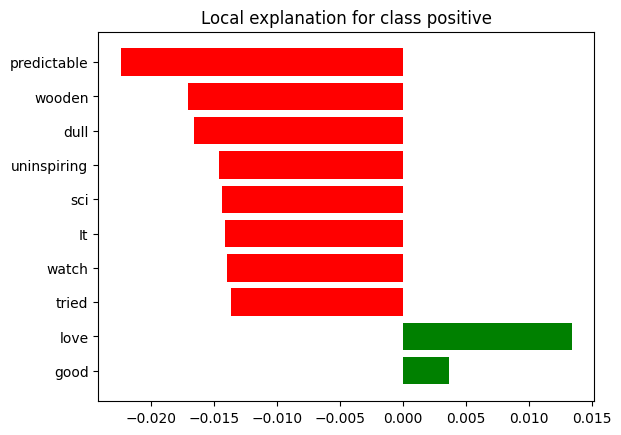

In [17]:
explainer_lime = LimeTextExplainer(
    class_names=["negative", "positive"]
)
exp = explainer_lime.explain_instance(
    test_dataset[0]["texts"],
    classify_fn,
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

In [18]:
test_dataset[-1]["true_label"]

'positive'

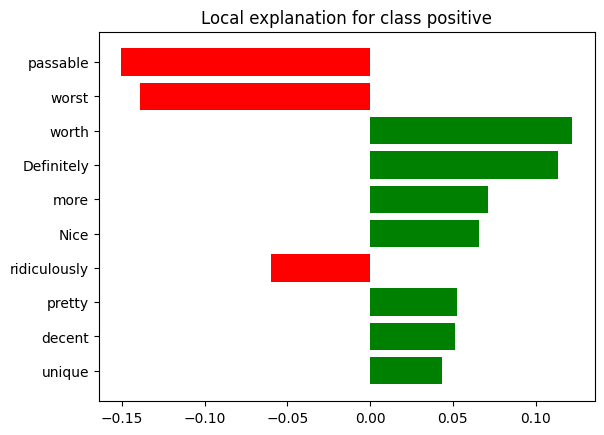

In [19]:
exp = explainer_lime.explain_instance(
    test_dataset[-1]["texts"],
    classify_fn,
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

## SHAP

PartitionExplainer explainer: 2it [00:15, 15.45s/it]               


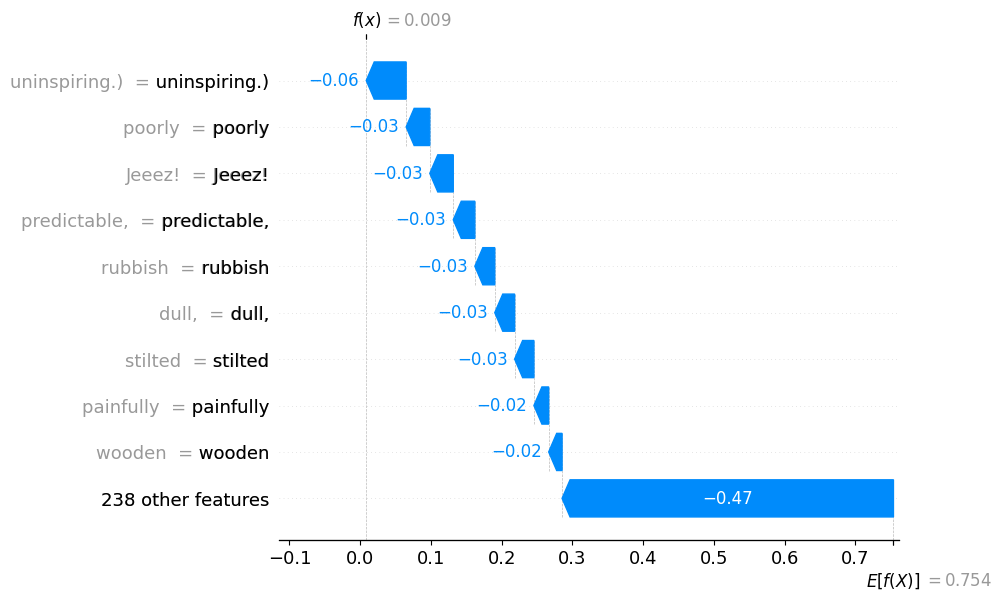

In [20]:
explainer_shap = shap.Explainer(
    classify_fn,
    shap.maskers.Text()
)
shap_values = explainer_shap([test_dataset[0]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

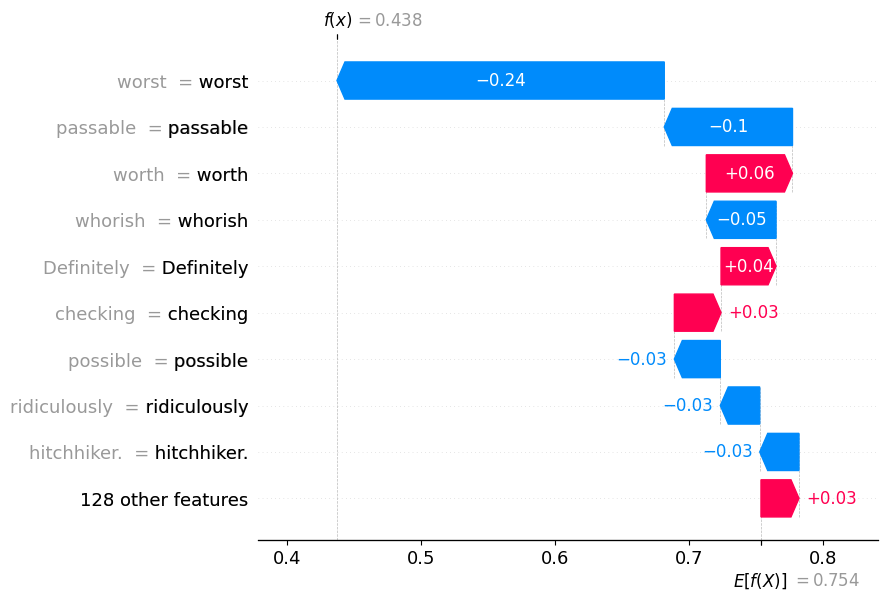

In [21]:
shap_values = explainer_shap([test_dataset[-1]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

## Integrated gradients

In [22]:
def integrated_gradients(model, input_ids, target_token_idx, steps=50):
    emb = model.get_input_embeddings()(input_ids)
    
    # baseline = embedding del token PAD
    pad_id = tokenizer.pad_token_id
    pad_token = torch.tensor([[pad_id]], device=input_ids.device)
    pad_emb = model.get_input_embeddings()(pad_token)  # [1, 1, hidden]
    baseline = pad_emb.expand_as(emb)  # [1, seq_len, hidden]
    
    grads = []
    for alpha in torch.linspace(0, 1, steps):
        interp = baseline + alpha * (emb - baseline)
        interp = interp.detach().requires_grad_(True)
        
        output = model(inputs_embeds=interp)
        score = output.logits[0, -1, target_token_idx]
        score.backward()
        
        grads.append(interp.grad.clone())
    
    avg_grads = torch.stack(grads).mean(dim=0)
    ig = (emb - baseline) * avg_grads
    return ig.norm(dim=-1).squeeze(0)  # [seq_len]

In [23]:
# preparar input
text = test_dataset[0]["texts"]
enc = tokenizer(text, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

# calcular IG para la clase positiva
ig_scores = integrated_gradients(
    model=teacher_model,
    input_ids=input_ids,
    target_token_idx=positive_id
)

In [58]:
def tokens_to_words(tokens, scores):
    words = []
    word_scores = []
    
    current_word = ""
    current_scores = []
    
    for token, score in zip(tokens, scores):
        # los tokens que continúan una palabra empiezan con "▁" en sentencepiece
        # o con "##" en wordpiece (BERT)
        if token.startswith("▁") or token.startswith("Ġ"):
            # nuevo token = nueva palabra
            if current_word:
                words.append(current_word)
                word_scores.append(np.mean(current_scores))
            current_word = token.lstrip("▁").lstrip("Ġ")
            current_scores = [score]
        else:
            current_word += token
            current_scores.append(score)
    
    # última palabra
    if current_word:
        words.append(current_word)
        word_scores.append(np.mean(current_scores))
    
    return words, np.array(word_scores)

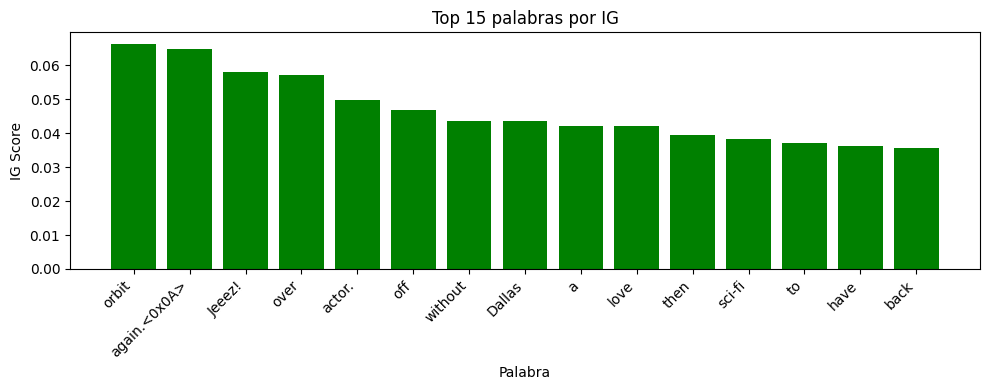

In [25]:
text = test_dataset[0]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(teacher_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

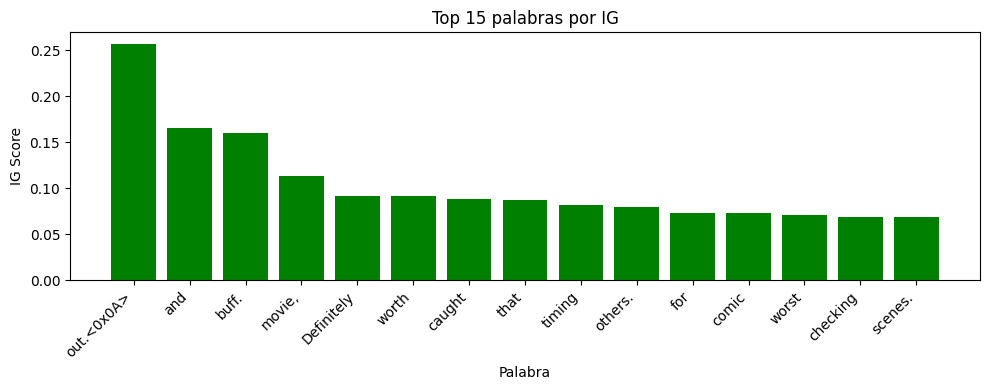

In [26]:
text = test_dataset[-1]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(teacher_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

In [27]:
teacher_model.cpu()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# Student model

In [53]:
# cargar config original
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    local_files_only=True
)

# student de 11 capas
config.num_hidden_layers = 11

In [ ]:
# crear arquitectura vacía
student_model = (
    AutoModelForCausalLM.from_config(
        config
    )
)

# cargar pesos
student_model.load_state_dict(
    torch.load(
        "../checkpoints/agnews/best_student_model.pt",
        map_location=device
    )
)

student_model.to(device)
student_model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

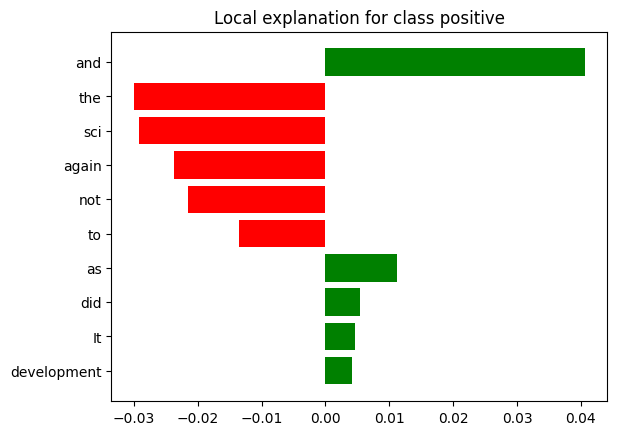

In [55]:
exp = explainer_lime.explain_instance(
    test_dataset[0]["texts"],
    lambda t: classify_fn(t, model=student_model),
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

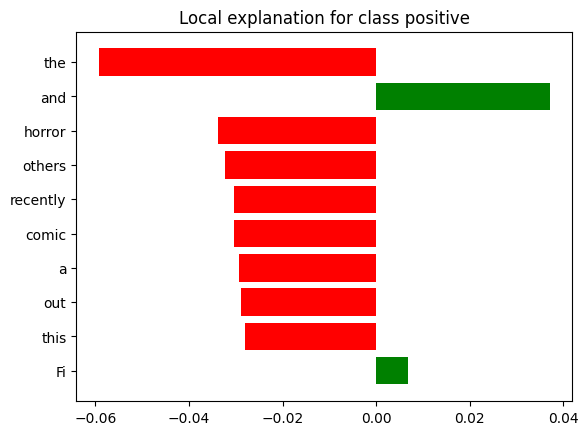

In [56]:
exp = explainer_lime.explain_instance(
    test_dataset[-1]["texts"],
    lambda t: classify_fn(t, model=student_model),
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

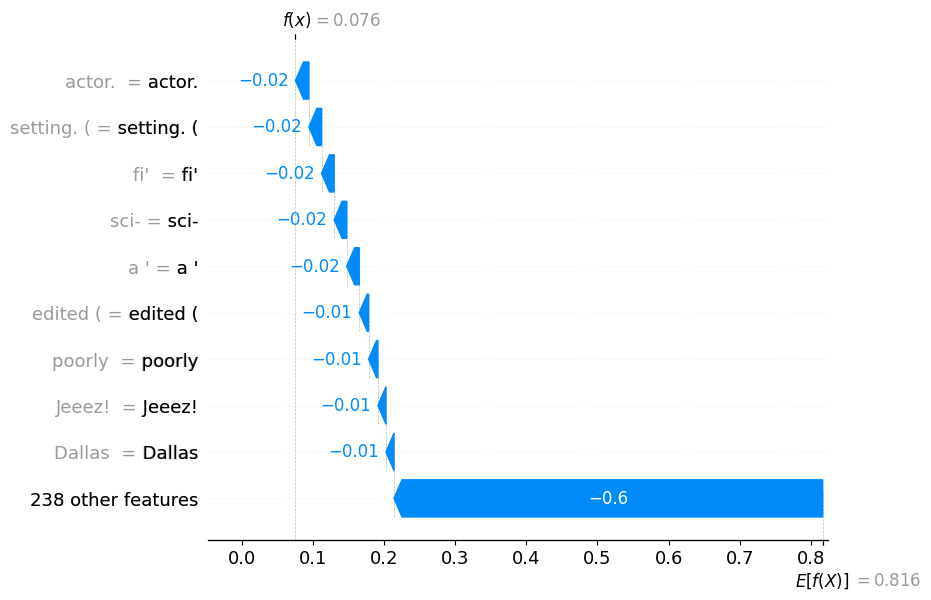

In [32]:
explainer_shap = shap.Explainer(
    lambda t: classify_fn(t, model=student_model),
    shap.maskers.Text()
)
shap_values = explainer_shap([test_dataset[0]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

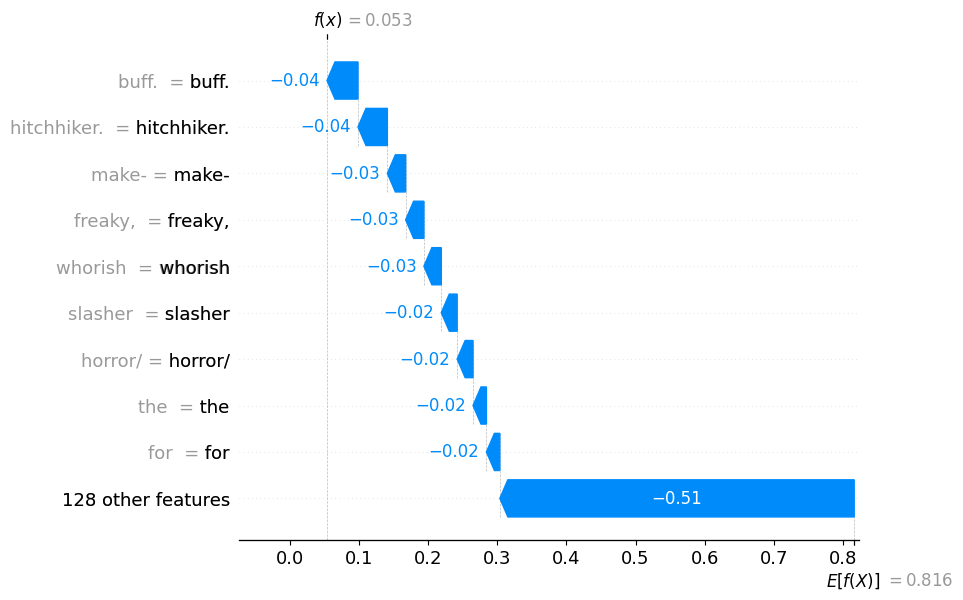

In [33]:
shap_values = explainer_shap([test_dataset[-1]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

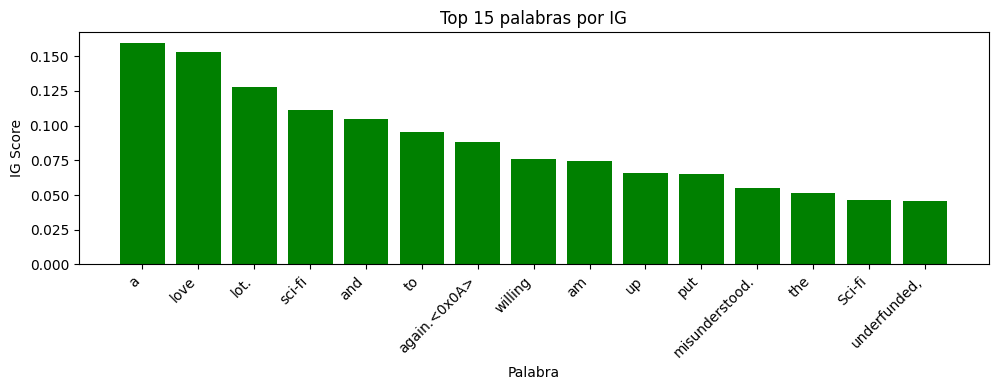

In [34]:
text = test_dataset[0]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(student_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

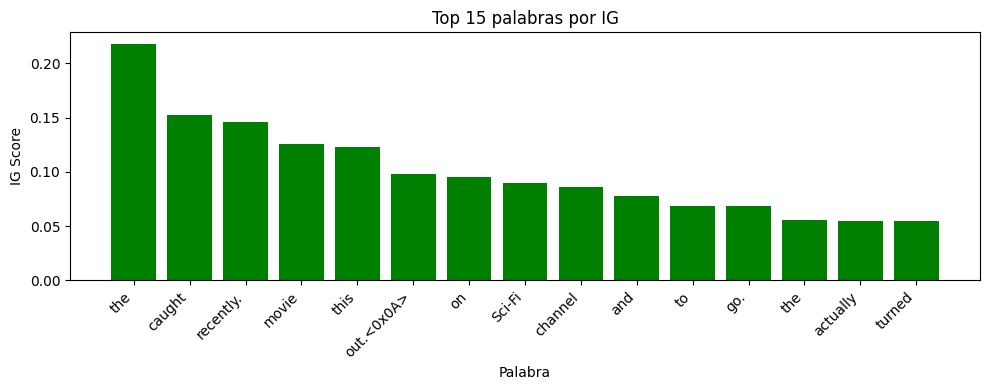

In [35]:
text = test_dataset[-1]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(student_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

In [57]:
student_model.cpu()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# Student local model

In [ ]:
# crear arquitectura vacía
student_local_model = (
    AutoModelForCausalLM.from_config(
        config
    )
)

# cargar pesos
student_local_model.load_state_dict(
    torch.load(
        "../checkpoints/agnews/best_student_local_model.pt",
        map_location=device
    )
)

student_local_model.to(device)
student_local_model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

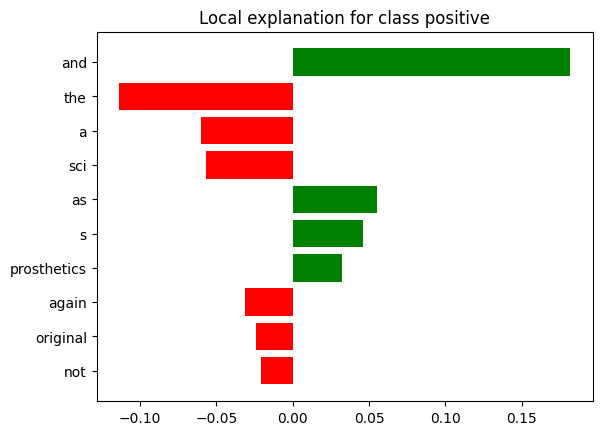

In [50]:
exp = explainer_lime.explain_instance(
    test_dataset[0]["texts"],
    lambda t: classify_fn(t, model=student_local_model),
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

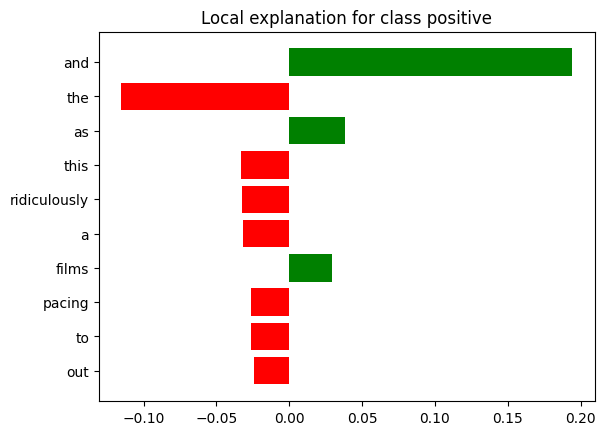

In [51]:
exp = explainer_lime.explain_instance(
    test_dataset[-1]["texts"],
    lambda t: classify_fn(t, model=student_local_model),
    num_samples=5000
)

exp.as_pyplot_figure()
plt.show()

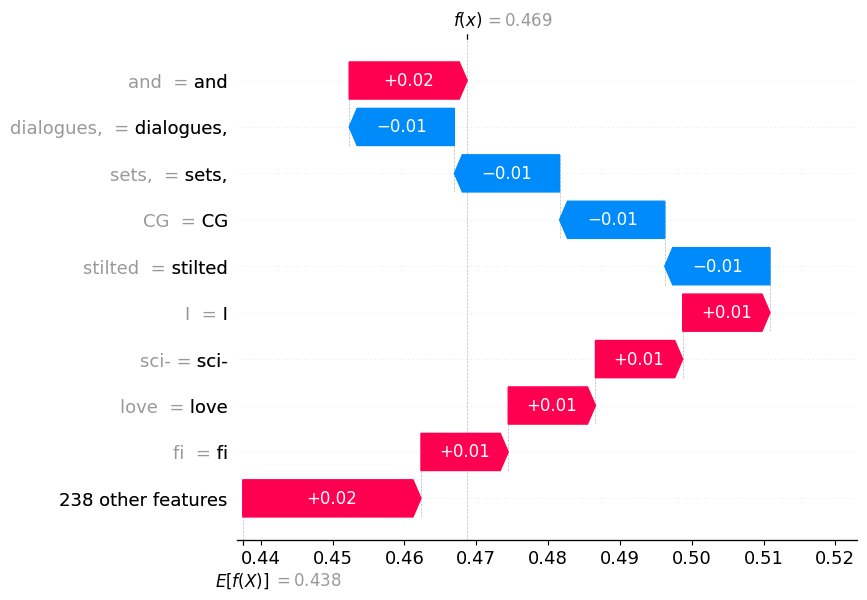

In [40]:
explainer_shap = shap.Explainer(
    lambda t: classify_fn(t, model=student_local_model),
    shap.maskers.Text()
)
shap_values = explainer_shap([test_dataset[0]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

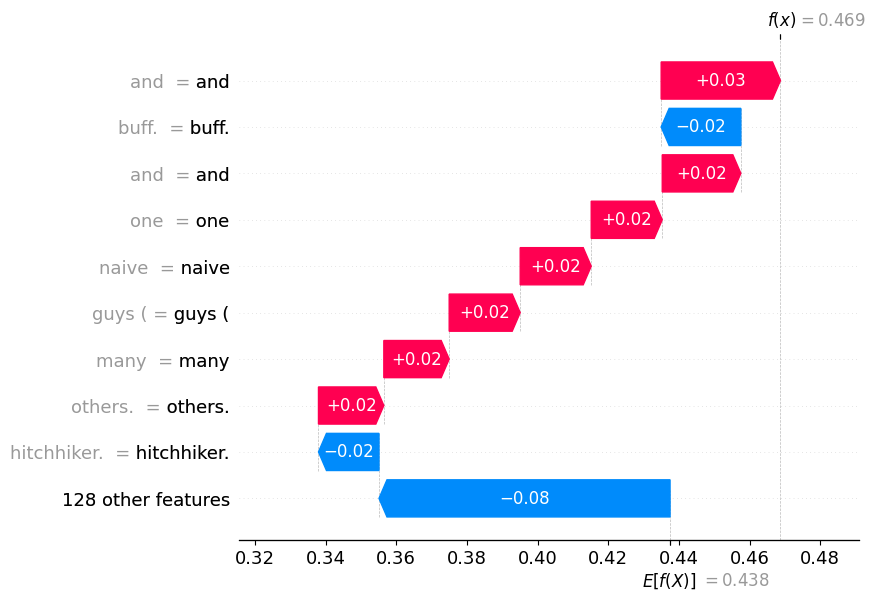

In [41]:
shap_values = explainer_shap([test_dataset[-1]["texts"]])

shap.plots.waterfall(shap_values[:, :, 1][0])

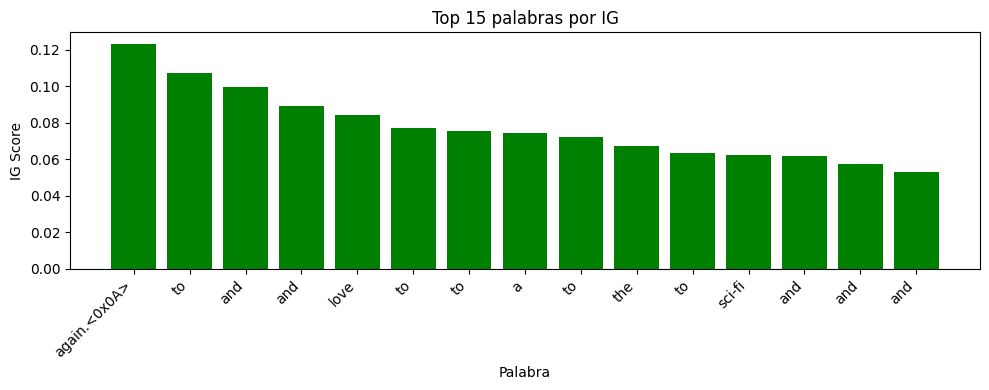

In [42]:
text = test_dataset[0]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(student_local_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

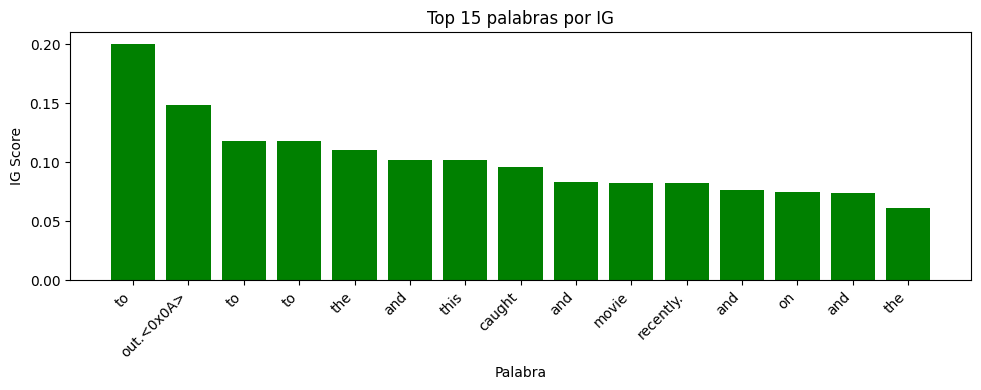

In [43]:
text = test_dataset[-1]["texts"]
prompt = make_prompt(text)

enc = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = enc["input_ids"]

ig_scores = integrated_gradients(student_local_model, input_ids, positive_id)

# calcular offset
prefix = "Review: "
prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
text_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

start = len(prefix_ids) + 1  # +1 por <s>
end = start + len(text_ids)

# recortar al texto
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_text = tokens[start:end]
scores_text = ig_scores.float().detach().cpu().numpy()[start:end]

# agregar por palabras
words, word_scores = tokens_to_words(tokens_text, scores_text, tokenizer)

# top N
top_n = 15
top_idx = np.argsort(np.abs(word_scores))[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_word_scores = word_scores[top_idx]

plt.figure(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in top_word_scores]
plt.bar(range(top_n), top_word_scores, color=colors)
plt.xticks(range(top_n), top_words, rotation=45, ha="right")
plt.xlabel("Palabra")
plt.ylabel("IG Score")
plt.title(f"Top {top_n} palabras por IG")
plt.tight_layout()
plt.show()

In [52]:
student_local_model.cpu()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# KL Comparisons

In [69]:
def compute_avg_kl(teacher, student, dataloader, device, temperature=1.0):
    teacher.eval()
    student.eval()
    
    total_kl = 0.0
    n = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            last_idx = attention_mask.sum(dim=1) - 1
            idx = torch.arange(input_ids.size(0), device=device)
            
            t_logits = teacher(input_ids=input_ids, attention_mask=attention_mask).logits[idx, last_idx]
            s_logits = student(input_ids=input_ids, attention_mask=attention_mask).logits[idx, last_idx]
            
            t_probs = F.softmax(t_logits / temperature, dim=-1)
            s_log_probs = F.log_softmax(s_logits / temperature, dim=-1)
            
            kl = F.kl_div(s_log_probs, t_probs, reduction="batchmean")
            total_kl += kl.item() * input_ids.size(0)
            n += input_ids.size(0)
    
    return total_kl / n

In [70]:
teacher_model.to(device)
student_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [71]:
kl_t1 = compute_avg_kl(teacher_model, student_model, test_loader, device, temperature=1.0)
kl_t2 = compute_avg_kl(teacher_model, student_model, test_loader, device, temperature=2.0)

print(f"KL (T=1): {kl_t1:.4f}")
print(f"KL (T=2): {kl_t2:.4f}")

KL (T=1): 5.8851
KL (T=2): 1.1011


In [72]:
student_model.cpu()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [73]:
student_local_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [74]:
kl_t1 = compute_avg_kl(teacher_model, student_local_model, test_loader, device, temperature=1.0)
kl_t2 = compute_avg_kl(teacher_model, student_local_model, test_loader, device, temperature=2.0)

print(f"KL (T=1): {kl_t1:.4f}")
print(f"KL (T=2): {kl_t2:.4f}")

KL (T=1): 9.2739
KL (T=2): 1.5785
